# Flight Pricing Notebook 03 
# Modele Predictif

L'Objectif ici est de construire un modele qui predit le prix d un billet et surtout comprendre la variable qui a le plus d'impact dans cette prediction.

L objectif n est PAS d avoir le meilleur score possible, mais un modele **interpretable et explicable** a un public non-technique.

**Plan :**
1. Preparation des features
2. Baseline naive
3. Random Forest + evaluation
4. Feature importance
5. Analyse des erreurs

In [1]:
import os
os.makedirs('../outputs', exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor
import warnings
warnings.filterwarnings('ignore')

COLORS = {
    'primary':   '#1B4F8A',
    'secondary': '#E8903A',
    'accent':    '#2ECC71',
    'danger':    '#E74C3C',
    'dark':      '#2C3E50'
}
PALETTE = ['#1B4F8A', '#E8903A', '#2ECC71', '#E74C3C', '#9B59B6', '#1ABC9C']

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../Portfolio-Pricing-Flights/flights_clean.csv')
print(f'Dataset charge : {df.shape[0]:,} lignes')

/Users/apiraami/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Dataset charge : 300,153 lignes


## 1. Preparation des features

In [2]:
df_model = df.copy()

stops_map = {'zero': 0, 'one': 1, 'two_or_more': 2}
df_model['stops_enc'] = df_model['stops'].map(stops_map)

time_map = {
    'Early_Morning': 0, 'Morning': 1, 'Afternoon': 2,
    'Evening': 3, 'Night': 4, 'Late_Night': 5
}
df_model['departure_enc'] = df_model['departure_time'].map(time_map)
df_model['arrival_enc']   = df_model['arrival_time'].map(time_map)

df_model['is_business'] = (df_model['class'] == 'Business').astype(int)

le = LabelEncoder()
df_model['airline_enc'] = le.fit_transform(df_model['airline'])
df_model['source_enc']  = le.fit_transform(df_model['source_city'])
df_model['dest_enc']    = le.fit_transform(df_model['destination_city'])

FEATURES = [
    'airline_enc', 'source_enc', 'dest_enc',
    'departure_enc', 'arrival_enc', 'stops_enc',
    'is_business', 'duration', 'days_left'
]

FEATURE_LABELS = [
    'Compagnie', 'Ville depart', 'Ville arrivee',
    'Creneau depart', 'Creneau arrivee', 'Nb escales',
    'Classe Business', 'Duree vol', 'Jours avant depart'
]

X = df_model[FEATURES]
y = df_model['price']

print(f'Features : {len(FEATURES)} variables')
print(f'X shape  : {X.shape}')
print(f'y range  : {y.min():,} a {y.max():,} INR')

Features : 9 variables
X shape  : (300153, 9)
y range  : 1,105 a 123,071 INR


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train : {X_train.shape[0]:,} | Test : {X_test.shape[0]:,}')

Train : 240,122 | Test : 60,031


## 2. Baseline naive

Avant tout modele complexe, on etablit une reference simple : predire la mediane pour tout le monde.

In [4]:
baseline = DummyRegressor(strategy='median')
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_baseline  = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline   = r2_score(y_test, y_pred_baseline)

print('Baseline (predire la mediane) :')
print(f'  RMSE : {rmse_baseline:,.0f} INR')
print(f'  MAE  : {mae_baseline:,.0f} INR')
print(f'  R2   : {r2_baseline:.4f}')

Baseline (predire la mediane) :
  RMSE : 26,398 INR
  MAE  : 16,155 INR
  R2   : -0.3519


## 3. Random Forest

In [9]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

amelioration = (1 - rmse_rf / rmse_baseline) * 100
print('Random Forest :')
print(f'  RMSE : {rmse_rf:,.0f} INR  (baseline : {rmse_baseline:,.0f} — amelioration : {amelioration:.1f}%)')
print(f'  MAE  : {mae_rf:,.0f} INR')
print(f'  R2   : {r2_rf:.4f}  (le modele explique {r2_rf*100:.1f}% de la variance du prix)')

Random Forest :
  RMSE : 3,321 INR  (baseline : 26,398 — amelioration : 87.4%)
  MAE  : 1,715 INR
  R2   : 0.9786  (le modele explique 97.9% de la variance du prix)


In [10]:
results = pd.DataFrame({
    'Modele':     ['Baseline (mediane)', 'Random Forest'],
    'RMSE (INR)': [f'{rmse_baseline:,.0f}', f'{rmse_rf:,.0f}'],
    'MAE (INR)':  [f'{mae_baseline:,.0f}', f'{mae_rf:,.0f}'],
    'R2':         [f'{r2_baseline:.4f}', f'{r2_rf:.4f}']
})
print(results.to_string(index=False))

            Modele RMSE (INR) MAE (INR)      R2
Baseline (mediane)     26,398    16,155 -0.3519
     Random Forest      3,321     1,715  0.9786


## 4. Feature Importance

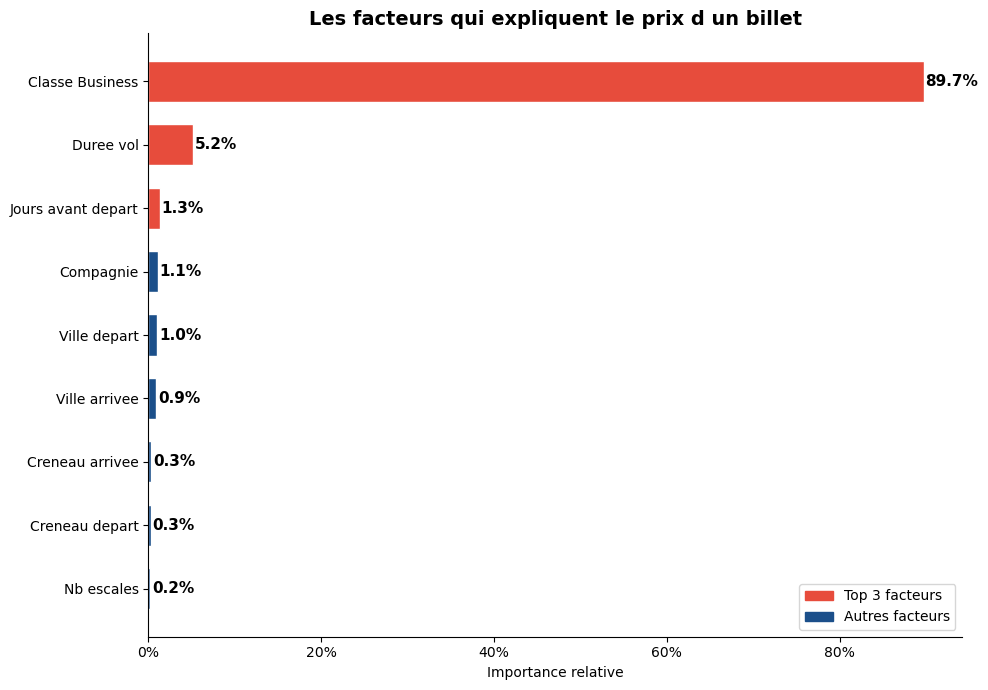

TOP 3 facteurs :
  Classe Business           : 89.7%
  Duree vol                 : 5.2%
  Jours avant depart        : 1.3%


In [11]:
importance_df = pd.DataFrame({
    'Feature':    FEATURE_LABELS,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

bar_colors = [
    COLORS['danger'] if i >= len(importance_df) - 3 else COLORS['primary']
    for i in range(len(importance_df))
]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    importance_df['Feature'], importance_df['Importance'],
    color=bar_colors, edgecolor='white', height=0.65
)

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val*100:.1f}%',
        va='center', fontweight='bold', fontsize=11
    )

ax.set_title('Les facteurs qui expliquent le prix d un billet', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance relative')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

top3  = mpatches.Patch(color=COLORS['danger'],  label='Top 3 facteurs')
other = mpatches.Patch(color=COLORS['primary'], label='Autres facteurs')
ax.legend(handles=[top3, other], loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('TOP 3 facteurs :')
for _, row in importance_df.tail(3).iloc[::-1].iterrows():
    print(f'  {row["Feature"]:25s} : {row["Importance"]*100:.1f}%')

## 5. Analyse des erreurs

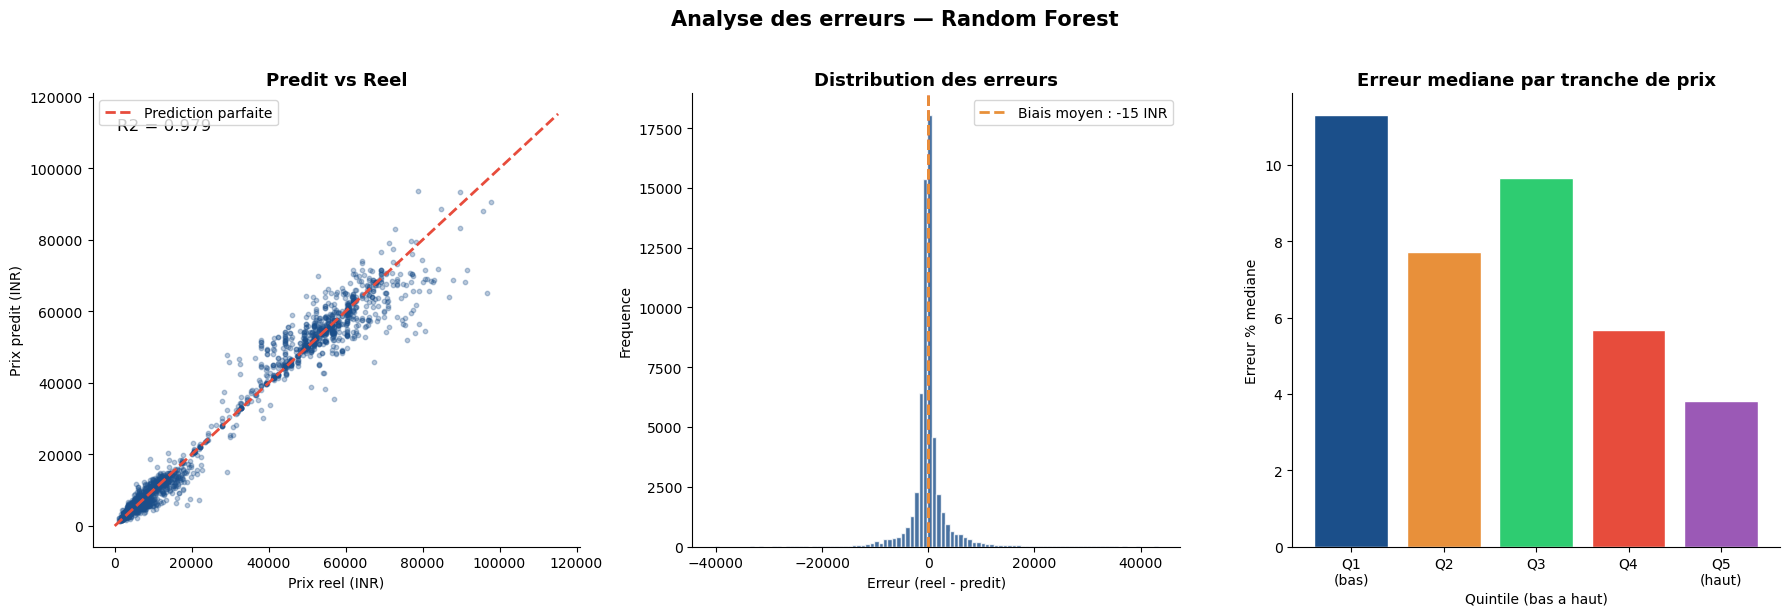

Erreur mediane : 7.0%
Erreur < 10%  : 59.7% des predictions
Erreur < 20%  : 81.0% des predictions


In [12]:
residuals = y_test - y_pred_rf
pct_error = abs(residuals) / y_test * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Predit vs Reel
sample = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
axes[0].scatter(
    y_test.values[sample], y_pred_rf[sample],
    alpha=0.3, color=COLORS['primary'], s=10
)
max_val = max(y_test.max(), y_pred_rf.max())
axes[0].plot([0, max_val], [0, max_val], '--', color=COLORS['danger'],
             linewidth=2, label='Prediction parfaite')
axes[0].set_title('Predit vs Reel', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prix reel (INR)')
axes[0].set_ylabel('Prix predit (INR)')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R2 = {r2_rf:.3f}',
             transform=axes[0].transAxes, fontsize=12)

# Distribution des residus
axes[1].hist(residuals, bins=100, color=COLORS['primary'], alpha=0.8, edgecolor='white')
axes[1].axvline(0, color=COLORS['danger'], linestyle='--', linewidth=2)
axes[1].axvline(
    residuals.mean(), color=COLORS['secondary'], linestyle='--',
    linewidth=2, label=f'Biais moyen : {residuals.mean():,.0f} INR'
)
axes[1].set_title('Distribution des erreurs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Erreur (reel - predit)')
axes[1].set_ylabel('Frequence')
axes[1].legend()

# Erreur par quintile de prix
price_bins = pd.qcut(y_test, q=5)
error_by_price = pd.DataFrame({
    'bin': price_bins, 'pct_error': pct_error
}).groupby('bin', observed=True)['pct_error'].median()

axes[2].bar(range(5), error_by_price.values, color=PALETTE[:5], edgecolor='white')
axes[2].set_title('Erreur mediane par tranche de prix', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Quintile (bas a haut)')
axes[2].set_ylabel('Erreur % mediane')
axes[2].set_xticks(range(5))
axes[2].set_xticklabels(['Q1\n(bas)', 'Q2', 'Q3', 'Q4', 'Q5\n(haut)'])

plt.suptitle('Analyse des erreurs — Random Forest', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/03_analyse_erreurs.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Erreur mediane : {pct_error.median():.1f}%')
print(f'Erreur < 10%  : {(pct_error < 10).mean()*100:.1f}% des predictions')
print(f'Erreur < 20%  : {(pct_error < 20).mean()*100:.1f}% des predictions')

---
## Synthese — Notebook 03

Completer apres execution :

- R2 : XX%
- Erreur mediane : XX%
- Top 3 features : XX, XX, XX

Prochaine etape — Notebook 04 : Recommandations finales